In [ ]:
import os
os.chdir("../")
%pwd

'e:\\MediBot'

In [2]:
import os
import fitz  # PyMuPDF
import base64
from pathlib import Path
from IPython.display import display, Image as IPImage, Markdown
from typing import List, Dict, Tuple

from langchain.schema import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate
from langchain.embeddings import HuggingFaceEmbeddings
from langchain_pinecone import PineconeVectorStore
from pinecone import Pinecone, ServerlessSpec
from dotenv import load_dotenv

load_dotenv()

c:\Users\jainm\.conda\envs\medibot\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [ ]:
IMAGE_OUTPUT_DIR = "extracted_imgs_physics"
os.makedirs(IMAGE_OUTPUT_DIR, exist_ok=True)

def extract_page_images(pdf_path: str, page_num: int) -> List[str]:
    """
    Extract all embedded images from a PDF page.
    Returns list of saved image file paths.
    """
    doc = fitz.open(pdf_path)
    page = doc[page_num]
    saved_paths = []

    for img in page.get_images():
        xref = img[0]
        pix = fitz.Pixmap(doc, xref)
        # Convert CMYK to RGB if needed
        if pix.n - pix.alpha > 3:
            pix = fitz.Pixmap(fitz.csRGB, pix)
        img_path = os.path.join(IMAGE_OUTPUT_DIR, f"page{page_num+1}_img{xref}.png")
        pix.save(img_path)
        saved_paths.append(img_path)

    doc.close()
    return saved_paths


def load_pdf_with_images(pdf_path: str):
    doc = fitz.open(pdf_path)
    docs = []
    page_images = {}
    filename = os.path.basename(pdf_path)

    for page_num in range(len(doc)):
        page = doc[page_num]
        text = page.get_text("text")

        # Tables
        blocks = page.get_text("blocks")
        table_texts = [b[4].strip() for b in blocks 
                       if "\t" in b[4] or b[4].count("  ") > 3]
        full_content = text
        if table_texts:
            full_content += "\n\n[TABLES]\n" + "\n".join(table_texts)

        if full_content.strip():
            docs.append(Document(
                page_content=full_content,
                metadata={"source": pdf_path, "page": page_num + 1}
            ))

        # ✅ Page rasterize karo — vector diagrams bhi capture honge
        mat = fitz.Matrix(1.5, 1.5)
        pix = page.get_pixmap(matrix=mat)
        img_path = os.path.join(IMAGE_OUTPUT_DIR, 
                                f"{filename}_page{page_num+1}.png")
        pix.save(img_path)
        page_images[page_num + 1] = [img_path]

    doc.close()
    return docs, page_images


# Build a lookup: image_path -> page_number (for retrieval matching)
def build_image_index(page_images: Dict[int, List[str]]) -> Dict[str, int]:
    idx = {}
    for page, paths in page_images.items():
        for p in paths:
            idx[p] = page
    return idx

In [7]:
PDF_PATH = "data/jesc1dd"

# Ab aise call karo — folder path dena hai
raw_docs, page_images = load_folder_with_images(PDF_PATH)
image_index = build_image_index(page_images)

print(f"Total pages with images: {len(page_images)}")
print(f"Sample pages with images: {list(page_images.keys())[:10]}")

Found 14 PDFs: ['jesc101.pdf', 'jesc102.pdf', 'jesc103.pdf', 'jesc104.pdf', 'jesc105.pdf', 'jesc106.pdf', 'jesc107.pdf', 'jesc108.pdf', 'jesc109.pdf', 'jesc110.pdf', 'jesc111.pdf', 'jesc112.pdf', 'jesc113.pdf', 'jesc1ps.pdf']
Processing: jesc101.pdf
Loaded 16 pages, 64 images extracted
Processing: jesc102.pdf
Loaded 20 pages, 51 images extracted
Processing: jesc103.pdf
Loaded 21 pages, 52 images extracted
Processing: jesc104.pdf
Loaded 21 pages, 58 images extracted
Processing: jesc105.pdf
Loaded 21 pages, 212 images extracted
Processing: jesc106.pdf
Loaded 13 pages, 33 images extracted
Processing: jesc107.pdf
Loaded 15 pages, 127 images extracted
Processing: jesc108.pdf
Loaded 6 pages, 93 images extracted
Processing: jesc109.pdf
Loaded 27 pages, 55 images extracted
Processing: jesc110.pdf
Loaded 10 pages, 25 images extracted
Processing: jesc111.pdf
Loaded 24 pages, 49 images extracted
Processing: jesc112.pdf
Loaded 13 pages, 31 images extracted
Processing: jesc113.pdf
Loaded 10 pages, 

In [8]:
def text_split(docs: List[Document]) -> List[Document]:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=20,
    )
    return splitter.split_documents(docs)

texts_chunk = text_split(raw_docs)
print(f"Total chunks: {len(texts_chunk)}")

Total chunks: 1213


In [9]:
def download_embeddings():
    return HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

embedding = download_embeddings()
print("Embedding model loaded")

C:\Users\jainm\AppData\Local\Temp\ipykernel_30480\2382291529.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  return HuggingFaceEmbeddings(


Embedding model loaded


In [11]:
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
GEMINI_API_KEY   = os.getenv("GEMINI_API_KEY")

os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY

pc = Pinecone(api_key=PINECONE_API_KEY)
index_name = "medical-chatbot-with-images-physics"

if not pc.has_index(index_name):
    pc.create_index(
        name=index_name,
        dimension=384,
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1")
    )

index = pc.Index(index_name)
print(f"Index ready: {index_name}")

Index ready: medical-chatbot-with-images-physics


In [12]:
# Run this ONCE to upsert. Comment out after first run.
docsearch = PineconeVectorStore.from_documents(
    documents=texts_chunk,
    embedding=embedding,
    index_name=index_name
)
print("Upsert complete")

Upsert complete


In [ ]:
# Load existing index (use this after first upsert)
docsearch = PineconeVectorStore.from_existing_index(
    index_name=index_name,
    embedding=embedding
)

retriever = docsearch.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

In [ ]:
# --- Gemini ---
from langchain_google_genai import ChatGoogleGenerativeAI
chatModel = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    google_api_key=GEMINI_API_KEY
)

# --- Ollama (uncomment to use locally) ---
# from langchain_ollama import ChatOllama
# chatModel = ChatOllama(model="llama3.2", temperature=0)

c:\Users\jainm\.conda\envs\medibot\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [ ]:
system_prompt = (
    "You are a Medical assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer "
    "the question. If the answer is not in the context, say that you "
    "don\'t know. Use three sentences maximum and keep the answer concise."
    "\n\n{context}"
)

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}"),
])

question_answer_chain = create_stuff_documents_chain(chatModel, prompt)
rag_chain = create_retrieval_chain(retriever, question_answer_chain)
print("RAG chain ready")

RAG chain ready


In [ ]:
def ask_with_images(question: str):
    """
    Run RAG query and display:
    - The LLM answer
    - Any relevant images from retrieved pages
    """
    response = rag_chain.invoke({"input": question})
    answer   = response["answer"]
    context_docs = response["context"]

    # ── Print answer
    display(Markdown(f"### Question\n{question}"))
    display(Markdown(f"### Answer\n{answer}"))

    # ── Find pages from retrieved docs
    retrieved_pages = set()
    for doc in context_docs:
        pg = doc.metadata.get("page")
        if pg:
            retrieved_pages.add(pg)

    # ── Show images from those pages
    shown = 0
    for page_num in sorted(retrieved_pages):
        imgs = page_images.get(page_num, [])
        for img_path in imgs:
            if os.path.exists(img_path):
                display(Markdown(f"*Relevant image — Page {page_num}:*"))
                display(IPImage(filename=img_path, width=400))
                shown += 1

    if shown == 0:
        display(Markdown("*No images found on retrieved pages.*"))

### Question
What is Acne?

### Answer
Acne is a common skin disease characterized by pimples on the face, chest, and back. It occurs when the pores of the skin become clogged with oil, dead skin cells, and bacteria. Medically known as acne vulgaris, it is a skin disorder in which the sebaceous glands become inflamed.

*Relevant image — Page 39.0:*

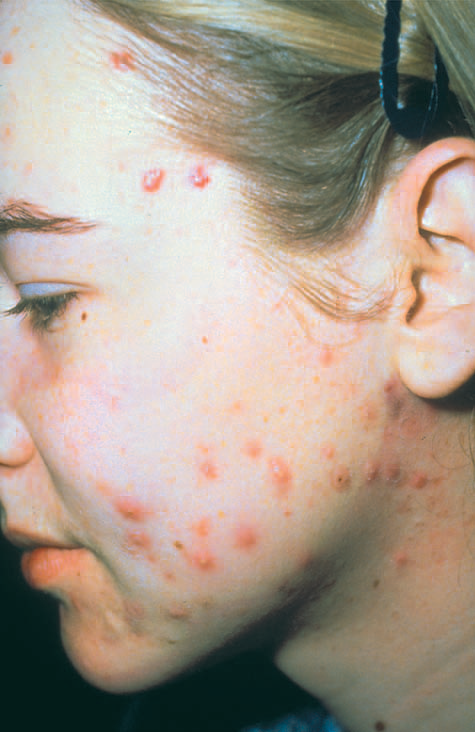

In [ ]:
ask_with_images("What is Acne?")

### Question
What is Acromegaly and gigantism?

### Answer
Acromegaly is a disorder caused by the abnormal release of a chemical from the pituitary gland, leading to increased growth in bone and soft tissue and other bodily disturbances. When this abnormality occurs before bone growth stops, it results in gigantism, characterized by unusual height. If it occurs after bone growth stops, the disorder is called acromegaly.

*Relevant image — Page 48.0:*

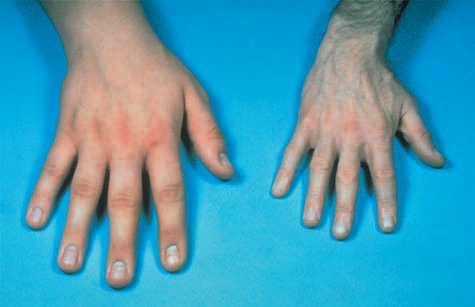

In [ ]:
ask_with_images("What is Acromegaly and gigantism?")

In [ ]:
ask_with_images("What is the treatment of Abscess?")

### Question
What is the treatment of Abscess?

### Answer
Treatment for an abscess may include antibiotics, aspirin or other medications for pain and fever, and anti-inflammatory drugs. Surgical drainage of the abscess may also be necessary. For smaller or superficial abscesses, hot compresses can be applied to encourage spontaneous pus release.

*No images found on retrieved pages.*

### Question
What causes skin abscess?

### Answer
Skin abscesses are nearly always caused by pus-forming (pyogenic) bacteria, most commonly Staphylococcus aureus. This bacterium often infects skin oil glands (sebaceous glands), leading to conditions like carbuncles and boils.

*Relevant image — Page 27.0:*

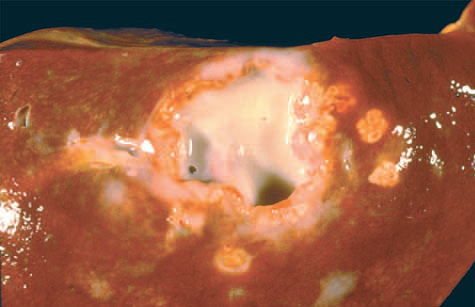

In [ ]:
# Custom question
question = "What causes skin abscess?"
ask_with_images(question)